# AAV9 real data — profile model

This notebook works with `aav9.csv`, a real NGS dataset from an AAV9 capsid
directed-evolution / viability experiment (not the simulated `Protocol` used
elsewhere in `Modelization_V1`). Each row is one observed 7-amino-acid variant
(the same `(num_amino_acids=20, num_positions=7)` convention as
`sequence_classesV1.Protocol`) with:


- `target` — the log enrichment of post-viability count over the input `plasmid` pool,
- `error` — an estimated uncertainty on `target` (bounded in `[0, 2]`; smaller
  for variants with more reads)

**Goal of this notebook (task 1):** build the **profile model** — the same
`F` object as `Protocol.F_viab`, a
`(num_amino_acids, num_positions)` matrix where `F[a, i]` says how good/bad
amino acid `a` is at position `i`. The logic being encoded is literally: *if
sequences with amino acid A at position 1 tend to have high (good) log
enrichment, position 1 / AA-A gets a positive profile weight* — and
symmetrically for every other (amino acid, position) pair.

In [1]:
import os
print(os.getcwd())

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/notebooks/aav_viability_test


### 0. Setup

In [2]:
import sys, os

# This notebook lives in "Modelization_V1/MLP regression/AAV viability test/", two levels
# below analysisV1.py / sequence_classesV1.py -- add Modelization_V1 so those sibling
# imports resolve (same convention as ProfileMLP_recovery_nnx.ipynb, one level up).
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes (analysisV1 imports jax)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_teacher_weights, plot_topk_recovery

# Only needed for section 8 (ProfileMLP), imported here so section 0 is the single setup point.
import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm
from sequence_classesV1 import ProtocolV2, initialize_random_weights

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 real-data profile model 1.1"


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


### 1. Load the data

In [3]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")
df.head()


68,776 variants, columns: ['sequence', 'target', 'error']


,sequence,target,error
0,AAACMFE,-7.167889,0.1
1,AAAFQEE,0.815779,0.1
2,AAAGCEN,-5.382741,0.1
3,AAALKGI,0.441829,0.1
4,AAANGCQ,-4.548073,0.1


### 1b. Target distribution

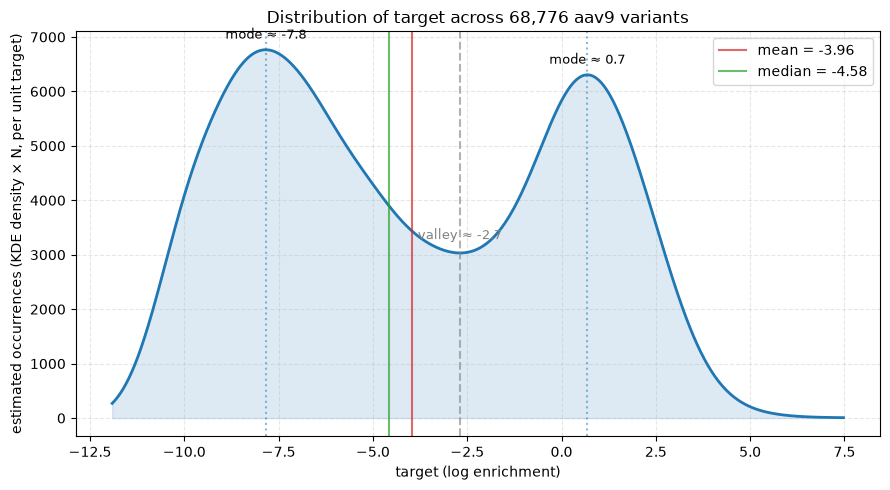

detected mode(s) at target ≈ [-7.84  0.68]


In [4]:
t = df["target"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t.min(), t.max(), 1000)
kde = gaussian_kde(t, bw_method=0.15)
occurrences = kde(grid) * len(t)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t.mean():.2f}")
ax.axvline(np.median(t), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t):.2f}")

ax.set_xlabel("target (log enrichment)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target across {len(t):,} aav9 variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target ≈ {np.round(grid[peaks], 2)}")


In [5]:
lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["sequence"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

print(f"num_positions={num_positions}  num_amino_acids={num_amino_acids}")

df[["target", "error"]].describe()


num_positions=7  num_amino_acids=20


,target,error
count,68776.000000,6.877600e+04
mean,-3.959911,1.000000e-01
std,4.209564,1.387789e-17
min,-11.911773,1.000000e-01
25%,-7.710318,1.000000e-01
50%,-4.583340,1.000000e-01
75%,0.087531,1.000000e-01
max,7.472986,1.000000e-01


In [6]:
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
target = df["target"].to_numpy()

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"seq_matrix[0] = {seq_matrix[0]}  ->  '{df['sequence'].iloc[0]}'")

seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
seq_matrix[0] = [ 0  0  0  1 10  4  3]  ->  'AAACMFE'


### 2. Building a supposed Ground Truth 

In [7]:
def F_groundtruth_viability(seq_matrix, target, num_amino_acids, num_positions):
    baseline = target.mean()
    F = np.full((num_amino_acids, num_positions), np.nan)
    counts = np.zeros((num_amino_acids, num_positions), dtype=int)
    for i in range(num_positions):
        for aa in range(num_amino_acids):
            mask = seq_matrix[:, i] == aa
            counts[aa, i] = mask.sum()
            if mask.any():
                F[aa, i] = target[mask].mean() - baseline
    return F, counts

F_viab_GT, counts = F_groundtruth_viability(seq_matrix=seq_matrix, target=df['target'].to_numpy(), num_amino_acids=num_amino_acids, num_positions=num_positions)

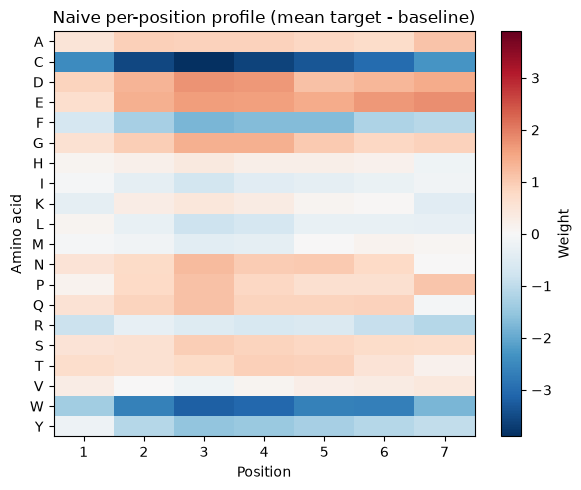

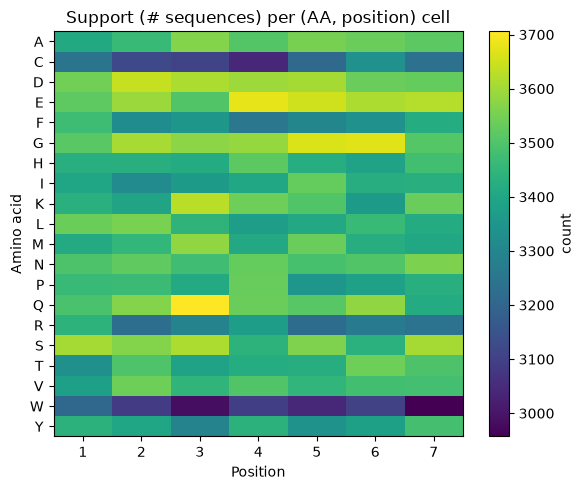

In [8]:
plot_teacher_weights(F_viab_GT, title="Naive per-position profile (mean target - baseline)")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(counts, aspect="auto", cmap="viridis")
ax.set_xlabel("Position")
ax.set_ylabel("Amino acid")
ax.set_xticks(range(num_positions))
ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
ax.set_yticks(range(num_amino_acids))
ax.set_yticklabels(AA_LABELS)
ax.set_title("Support (# sequences) per (AA, position) cell")
fig.colorbar(im, ax=ax, label="count")
fig.tight_layout()
plt.show()


### 3. Learning the profile weights with an MLP

In [9]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same building blocks as SimpleMLP
    (Linear + BatchNorm + Dropout + gelu), with input_dim=L*A: one-hot gives the network
    the categorical amino-acid structure for free, so it only has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- on top of that, instead of also
    having to rediscover the categorical structure from a raw integer index.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [10]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [11]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    """
    model : optional existing ProfileMLP to continue training from (warm start) instead of
    initializing a fresh one.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


In [12]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.5, random_state=0)
y_train, y_test    = target[idx_train], target[idx_test]

### ------------ One Hot Encoding ------------ ###
# Raw per-position indices (0..19, AA_LABELS' alphabetical order) carry no numeric
# meaning -- amino acid 3 isn't "between" 2 and 4 in any biological sense -- so feeding
# them straight into nnx.Linear as floats forces the network to first rediscover the
# one-hot structure from scratch before it can learn anything else. One-hot expands
# each position into a length-20 indicator vector instead: (N, 7) -> (N, 7, 20) -> (N, 140).
seq_oh = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix]  # (N, L, A)
seq_oh = seq_oh.reshape(len(df), -1)                             # (N, L*A)

X_mlp_train_full = seq_oh[idx_train]
X_mlp_test        = seq_oh[idx_test]

print(f"X_mlp_train_full shape is {X_mlp_train_full.shape}")

Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp = split_train_val(X_mlp_train_full, y_train, val_frac=0.15, seed=0)
print(f"ProfileMLP -- train: {len(Xtr_mlp):,}  val: {len(Xva_mlp):,}  test: {len(X_mlp_test):,}")

model_mlp, hist_mlp = train_profile_mlp(Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp, seed=0)


X_mlp_train_full shape is (34388, 140)
ProfileMLP -- train: 29,230  val: 5,158  test: 34,388


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:   0%|          | 1/300 [00:06<34:32,  6.93s/it]

Training ProfileMLP:   2%|▏         | 7/300 [00:07<03:36,  1.35it/s]

Training ProfileMLP:   5%|▍         | 14/300 [00:07<01:27,  3.27it/s]

...

Training ProfileMLP:  14%|█▍        | 42/300 [00:07<00:14, 18.12it/s]

Training ProfileMLP:  16%|█▋        | 49/300 [00:07<00:10, 23.85it/s]

Training ProfileMLP:  19%|█▊        | 56/300 [00:07<00:08, 29.68it/s]

Training ProfileMLP:  20%|██        | 61/300 [00:07<00:30,  7.73it/s]

Early stopping at epoch 61 (best val MSE=3.0319)


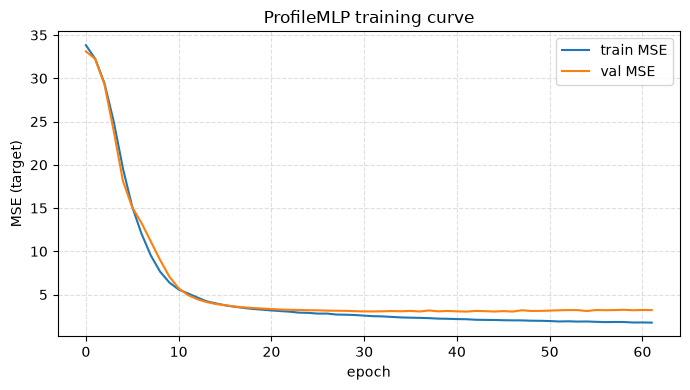

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_mlp["train_loss"], label="train MSE")
ax.plot(hist_mlp["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (target)")
ax.set_title("ProfileMLP training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This is a top-k% precision/recovery check restricted to the <b>held-out test split</b> (<code>idx_test</code>, ~34,388 of the 68,776 real aav9.csv sequences) — not the full library and not a brute-force theoretical population. It measures whether the model's own ranking on unseen real data recovers the true best sequences.
</div>

Pearson r (train): 0.9676
Pearson r (test):  0.9134

Held-out (test) top-k recovery:
  Top   1%   precision = 0.149   (random baseline = 0.010)
  Top   5%   precision = 0.422   (random baseline = 0.050)
  Top  10%   precision = 0.585   (random baseline = 0.100)
  Top  20%   precision = 0.740   (random baseline = 0.200)


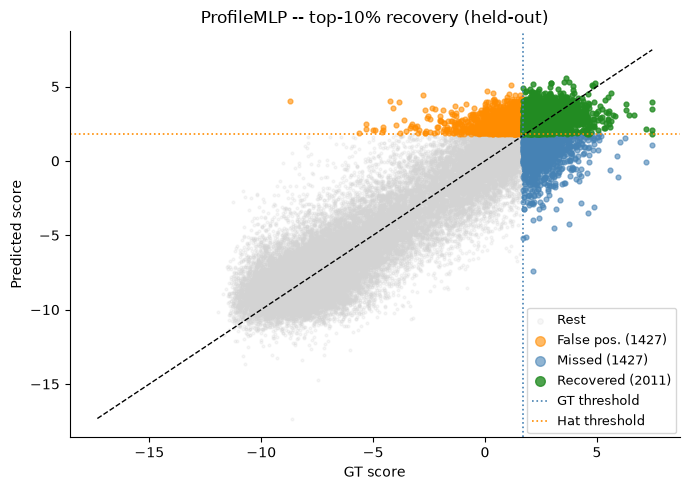

In [14]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)

pred_train_mlp = np.asarray(predict_scores(model_mlp, jnp.asarray(Xtr_mlp)))
pred_test_mlp  = np.asarray(predict_scores(model_mlp, jnp.asarray(X_mlp_test)))

print(f"Pearson r (train): {pearson(ytr_mlp, pred_train_mlp):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test_mlp):.4f}")
print()
print("Held-out (test) top-k recovery:")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test_mlp, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_test, pred_test_mlp, k_frac=0.10, title="ProfileMLP -- top-10% recovery (held-out)")
plt.show()


In [15]:
def extract_effective_F(model, backgrounds, L=num_positions, A=num_amino_acids, batch_size=8192):
    """
    Single-mutant scan against real background sequences: for a background s and mutation
    p->a, M(s^{p->a}) - M(s) isolates f_p(a) only up to terms that depend on s's other
    positions. Averaged over many backgrounds, F is recovered up to a global additive
    constant.

    backgrounds : (M, L) real sequences as raw amino-acid indices, e.g. a random subsample
                  of seq_matrix. Mutants are built in raw-index space (simplest way to flip
                  a single position), then one-hot encoded right before scoring since model
                  now expects one-hot (N, L*A) input, matching training.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    x_all    = np.concatenate([backgrounds, single_mutants], axis=0)      # (n, L) raw indices
    x_all_oh = np.eye(A, dtype=np.float32)[x_all].reshape(x_all.shape[0], -1)  # (n, L*A) one-hot

    scores_chunks = []
    for start in range(0, x_all_oh.shape[0], batch_size):
        chunk = jnp.asarray(x_all_oh[start : start + batch_size])
        scores_chunks.append(np.asarray(predict_scores(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M:].reshape(M, L, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = F_flat.T.astype(np.float32)               # (A, L)
    return F_hat


rng_bg      = np.random.default_rng(0)
M_backgrounds = 256
bg_idx      = rng_bg.choice(seq_matrix.shape[0], size=M_backgrounds, replace=False)
backgrounds = seq_matrix[bg_idx]

F_mlp = extract_effective_F(model_mlp, backgrounds)


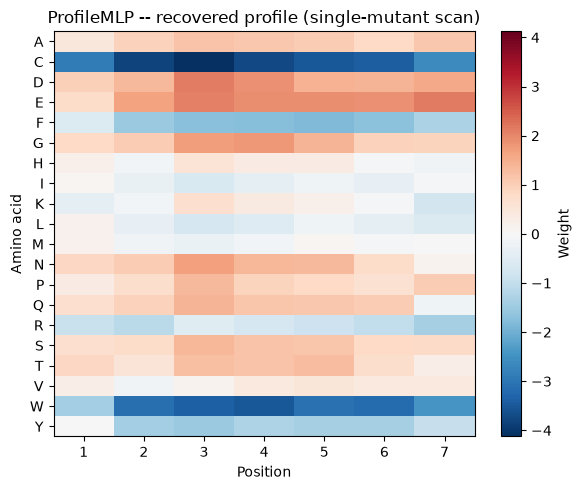

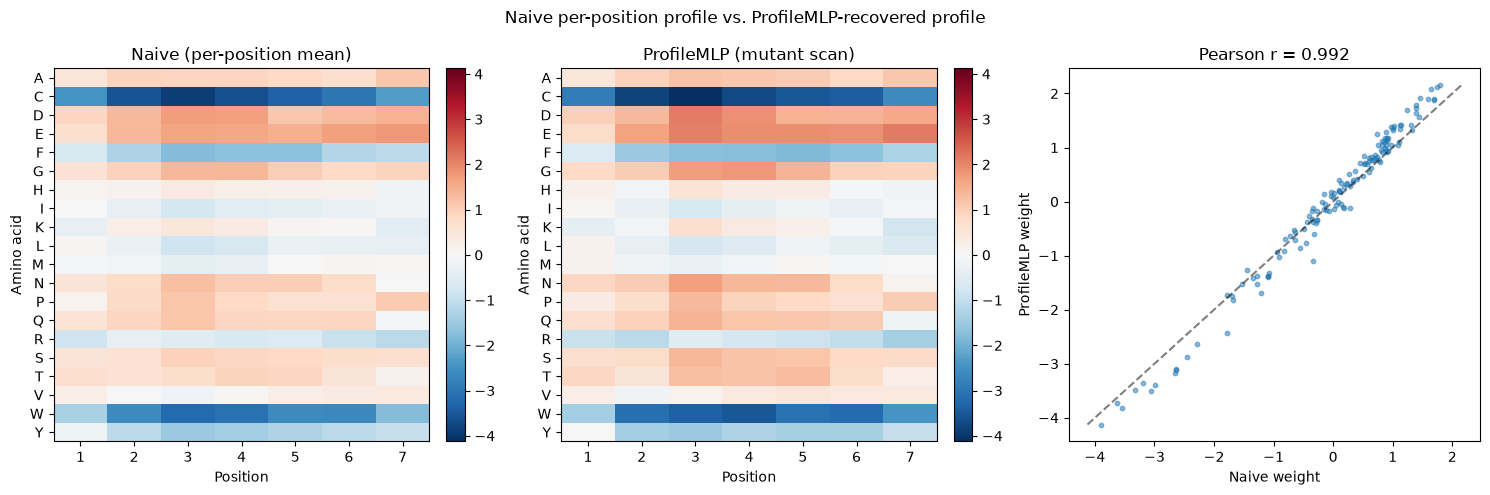

In [16]:
plot_teacher_weights(F_mlp, title="ProfileMLP -- recovered profile (single-mutant scan)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = max(np.abs(F_viab_GT).max(), np.abs(F_mlp).max())

for ax, F, title in [(axes[0], F_viab_GT, "Naive (per-position mean)"), (axes[1], F_mlp, "ProfileMLP (mutant scan)")]:
    im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amino acid")
    ax.set_xticks(range(num_positions))
    ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
    ax.set_yticks(range(num_amino_acids))
    ax.set_yticklabels(AA_LABELS)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

r_profiles = pearson(F_viab_GT.ravel(), F_mlp.ravel())
axes[2].scatter(F_viab_GT.ravel(), F_mlp.ravel(), s=10, alpha=0.5)
lims = [min(F_viab_GT.min(), F_mlp.min()), max(F_viab_GT.max(), F_mlp.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive weight")
axes[2].set_ylabel("ProfileMLP weight")
axes[2].set_title(f"Pearson r = {r_profiles:.3f}")

fig.suptitle("Naive per-position profile vs. ProfileMLP-recovered profile")
fig.tight_layout()
plt.show()


### 3b. Pairwise (J) interactions: naive vs ProfileMLP

Section 2's naive profile only captures each position's own AVERAGE effect — it can't see
whether two positions interact (e.g. amino acid A being good at position 1 only when
position 4 has amino acid B). This extends the same two recipes already used for `F` to the
pairwise coupling `J`:

- **Naive J** — the same "group real sequences and average their target" logic as
  `F_groundtruth_viability`, extended to position PAIRS: for every (position i, position j,
  amino acid a, amino acid b), average the target of sequences that actually carry (a at i)
  AND (b at j), then subtract off the baseline and each position's own naive single-site
  effect (already known from `F_viab_GT`) — what's left over is the naive pairwise term.
- **ProfileMLP J** — `extract_effective_F`'s single-mutant scan extended to a DOUBLE-mutant
  scan against the already-trained `model_mlp` (same idea as `extract_effective_FJ` in
  `DEEPMLP_nnx_recovery.ipynb`, minus that notebook's `T` temperature scaling — real `target`
  isn't on that simulated scale).

The two are then compared directly: per-position-pair coupling-strength heatmaps side by
side, plus a raw-entry scatter restricted to cells where the naive estimate had enough real
sequences behind it to be trustworthy.

In [17]:
def J_groundtruth_naive(seq_matrix, target, F, baseline, num_amino_acids, num_positions, min_support=5):
    """
    Naive per-pair pairwise-interaction estimate: for every position pair (i, j) and
    amino-acid pair (a, b), take the mean target of the real sequences that actually carry
    (a at i) AND (b at j), then subtract off what the baseline and each position's own
    single-site naive effect (F[a, i], F[b, j]) already explain -- what's left over is the
    naive estimate of positions i/j's PAIRWISE (epistatic) contribution, J[i, j, a, b].
    Mirrors J[j, i, b, a] = J[i, j, a, b], matching sequence_classesV1.build_J's convention.

    Returns
    -------
    J        : (L, L, A, A) naive interaction estimate, NaN on the diagonal and on any cell
               with fewer than `min_support` supporting sequences -- kept for backward
               compatibility with the naive-vs-MLP comparison further below.
    support  : (L, L, A, A) raw supporting-sequence counts.
    J_raw    : same estimate as J but computed for EVERY cell with >=1 supporting sequence
               (no min_support cutoff) -- the un-gated naive retrieval, used by 3c's
               continuous credibility-weighted attenuation instead of a hard cutoff.
    J_se     : (L, L, A, A) standard error of J_raw's mean, std(target[mask], ddof=1)/sqrt(n)
               for n>=2; a cell with a single supporting sequence has no way to estimate its
               own noise (left at +inf -- maximally shrunk under the attenuation in 3c).
    """
    L, A = num_positions, num_amino_acids
    J       = np.full((L, L, A, A), np.nan)
    J_raw   = np.full((L, L, A, A), np.nan)
    J_se    = np.full((L, L, A, A), np.inf)
    support = np.zeros((L, L, A, A), dtype=int)

    # Precompute each position's per-amino-acid boolean mask once, reused across every
    # partner position instead of recomputing "sequence has amino acid a at position i"
    # A*(L-1) times.
    position_masks = [[seq_matrix[:, i] == a for a in range(A)] for i in range(L)]

    for i in range(L):
        for j in range(i + 1, L):
            for a in range(A):
                mask_a = position_masks[i][a]
                if not mask_a.any():
                    continue
                for b in range(A):
                    mask = mask_a & position_masks[j][b]
                    n = int(mask.sum())
                    support[i, j, a, b] = support[j, i, b, a] = n
                    if n >= 1:
                        vals_t = target[mask]
                        val = vals_t.mean() - baseline - F[a, i] - F[b, j]
                        J_raw[i, j, a, b] = J_raw[j, i, b, a] = val
                        if n >= 2:
                            se = vals_t.std(ddof=1) / np.sqrt(n)
                            J_se[i, j, a, b] = J_se[j, i, b, a] = se
                        if n >= min_support:
                            J[i, j, a, b] = J[j, i, b, a] = val
    return J, support, J_raw, J_se


J_naive, support_naive, J_naive_raw, J_naive_se = J_groundtruth_naive(
    seq_matrix, target, F_viab_GT, baseline=target.mean(),
    num_amino_acids=num_amino_acids, num_positions=num_positions, min_support=5,
)

off_diag = ~np.eye(num_positions, dtype=bool)
print(f"J_naive: {(~np.isnan(J_naive)).sum():,} / {J_naive.size:,} cells filled "
      f"({np.isnan(J_naive[off_diag]).mean() * 100:.1f}% of off-diagonal cells still NaN, "
      f"median support {np.median(support_naive[off_diag]):.0f} sequences/cell)")
print(f"J_naive_raw (no cutoff, every cell with >=1 supporting sequence): "
      f"{(support_naive[off_diag] == 0).mean() * 100:.1f}% of off-diagonal cells truly never "
      f"co-observed in aav9.csv (support=0, forced to 0 downstream)")


J_naive: 16,800 / 19,600 cells filled (0.0% of off-diagonal cells still NaN, median support 172 sequences/cell)
J_naive_raw (no cutoff, every cell with >=1 supporting sequence): 0.0% of off-diagonal cells truly never co-observed in aav9.csv (support=0, forced to 0 downstream)


In [18]:
def extract_effective_FJ_mlp(model, backgrounds, L=num_positions, A=num_amino_acids, batch_size=8192):
    """
    Double-mutant scan against the same `backgrounds` used by `extract_effective_F`'s
    single-mutant scan: for a background s and a JOINT mutation (p->a, q->b),
    M(s^{p->a,q->b}) - M(s) isolates f_p(a) + f_q(b) + j_pq(a,b), up to terms that depend on
    s's other positions. Averaged over backgrounds, subtracting the single-site effects
    (recomputed here from the SAME scan, so they're self-consistent with the pairwise term)
    leaves j_pq(a,b) -- the model's own effective pairwise coupling. Same "zero-sum-gauge"
    caveat as DEEPMLP_nnx_recovery.ipynb's extract_effective_FJ (each position's row/column
    mean is already subtracted out of J), but with no `T` scaling: this model was trained
    directly on the real (already-log-scale) target, unlike the simulated Protocol's
    T-normalized scores.

    Returns
    -------
    F_hat, J_hat : (A, L) single-site effects (same convention as extract_effective_F) and
    (L, L, A, A) pairwise couplings (NaN on the diagonal i==j, where "interaction" is
    undefined).
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    pairs    = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n_pairs  = len(pairs)
    n_double = M * n_pairs * A * A
    double_mutants = np.repeat(backgrounds, n_pairs * A * A, axis=0)
    pair_pattern   = np.repeat(np.arange(n_pairs), A * A)
    aai_block      = np.repeat(np.arange(A), A)
    aaj_block      = np.tile(np.arange(A), A)
    i_of_pair      = np.array([p[0] for p in pairs])
    j_of_pair      = np.array([p[1] for p in pairs])
    tiled_i        = np.tile(i_of_pair[pair_pattern], M)
    tiled_j        = np.tile(j_of_pair[pair_pattern], M)
    tiled_aai      = np.tile(np.tile(aai_block, n_pairs), M)
    tiled_aaj      = np.tile(np.tile(aaj_block, n_pairs), M)
    rows           = np.arange(n_double)
    double_mutants[rows, tiled_i] = tiled_aai
    double_mutants[rows, tiled_j] = tiled_aaj

    x_all = np.concatenate([backgrounds, single_mutants, double_mutants], axis=0)  # (n, L) raw indices

    # One-hot encoded and scored batch by batch -- x_all alone is ~2.2M rows here (256
    # backgrounds x (1 + L*A + n_pairs*A*A) mutants each), encoding it to one-hot all at once
    # would briefly need >1GB; chunking keeps peak memory small.
    scores_chunks = []
    for start in range(0, x_all.shape[0], batch_size):
        chunk_oh = np.eye(A, dtype=np.float32)[x_all[start : start + batch_size]].reshape(-1, L * A)
        scores_chunks.append(np.asarray(predict_scores(model, jnp.asarray(chunk_oh))))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M : M + n_single].reshape(M, L, A)
    double_scores = scores[M + n_single :].reshape(M, n_pairs, A, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = F_flat.T.astype(np.float32)               # (A, L), matches extract_effective_F

    double_avg = double_scores.mean(axis=0)  # (n_pairs, A, A)
    J_hat = np.full((L, L, A, A), np.nan, dtype=np.float32)
    for k, (i, j) in enumerate(pairs):
        delta_ij    = double_avg[k] - mean_score - F_flat[i][:, None] - F_flat[j][None, :]
        J_hat[i, j] = delta_ij
        J_hat[j, i] = delta_ij.T
    return F_hat, J_hat


F_mlp_fj, J_mlp = extract_effective_FJ_mlp(model_mlp, backgrounds)
print(f"Pearson r (F_mlp_fj vs F_mlp, sanity check -- same scan run twice): "
      f"{pearson(F_mlp.ravel(), F_mlp_fj.ravel()):.4f}")


Pearson r (F_mlp_fj vs F_mlp, sanity check -- same scan run twice): 1.0000


### 3c. Credible GT: naive retrieval + attenuation of aberrant `J` coefficients

Looking at the best variants scored over the full theoretical `20**7 ~= 1.28e9`-sequence
space (not just the real `aav9.csv` library), the top of that ranking can be dominated by a
strongly *negative* `F_part` paired with a strongly *positive* `J_part` -- i.e. combinations
of amino acids that are individually bad, apparently "rescued" by a large pairwise term.

**Project decision: the exported GT must not come from any MLP-generated matrix** -- neither
`model_mlp`'s probed `F_mlp`/`J_mlp` (above) nor `model_pair`'s directly-fit parameters
(section 5 below). An MLP-derived `J` can extrapolate into (i, j, a, b) combinations barely
seen in the real data, producing large but not-credible couplings. The goal here isn't a
maximally *precise* GT, it's a *credible* one:

1. **Naive retrieval** -- `F_viab_GT`/`J_naive_raw` (section 2 / above): plain group-means of
   the real `aav9.csv` data, no learned model in the loop.
2. **Attenuate the `J` cells with too little real support to trust** -- replacing the earlier
   hard `min_support` NaN cutoff with a continuous, credibility-weighted L2/ridge shrinkage
   using each cell's own real-data standard error: cells backed by few real sequences are
   pulled hard toward 0, cells backed by many are barely touched. `F_viab_GT` needs no such
   treatment: its ~140 cells each average ~490 real sequences of support, orders of magnitude
   more than any single `J` cell gets out of the same 68,776 rows.

Checked and visualized below (reusing `AAV_MLP_weights_recovery.ipynb`'s per-variant `J` grid
visual for the before/after matrices).

In [19]:
rng_bf   = np.random.default_rng(0)
N_BF     = 2_000_000
TOP_K_BF = 500
seq_bf      = rng_bf.integers(0, num_amino_acids, size=(N_BF, num_positions))
baseline_bf = float(target.mean())

J_naive_before = np.nan_to_num(J_naive_raw, nan=0.0)  # cells never co-observed (support=0):
                                                        # no evidence of interaction -> 0

def score_FJ(seq, F, J, baseline):
    """(N, L) raw amino-acid indices -> F_part, J_part, total = baseline + F_part + J_part.
    Same additive+pairwise convention as F_groundtruth_viability/J_groundtruth_naive (this is
    exactly how sequence_classesV1.Protocol scores a sequence from F_viab/J_viab downstream)."""
    L = seq.shape[1]
    F_part = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    J_part = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            J_part += J[i, j, seq[:, i], seq[:, j]]
    return F_part, J_part, baseline + F_part + J_part

F_part_bf, J_part_bf, total_bf = score_FJ(seq_bf, F_viab_GT, J_naive_before, baseline_bf)
top_idx_bf = np.argsort(-total_bf)[:TOP_K_BF]

print(f"Brute-force top-{TOP_K_BF} of {N_BF:,} random sequences drawn uniformly from the full "
      f"{num_amino_acids}**{num_positions} = {num_amino_acids ** num_positions:,}-sequence space, "
      f"scored with the NAIVE GT F_viab_GT/J_naive_raw (no MLP involved):")
print(f"  top-{TOP_K_BF}      F_part: mean={F_part_bf[top_idx_bf].mean():+.2f}  median={np.median(F_part_bf[top_idx_bf]):+.2f}   "
      f"J_part: mean={J_part_bf[top_idx_bf].mean():+.2f}  median={np.median(J_part_bf[top_idx_bf]):+.2f}")
print(f"  random background  F_part: mean={F_part_bf.mean():+.2f}                          "
      f"J_part: mean={J_part_bf.mean():+.2f}")
print(f"  {(J_part_bf[top_idx_bf] > 0).mean()*100:.1f}% of the top-{TOP_K_BF} have POSITIVE J_part "
      f"(vs {(J_part_bf > 0).mean()*100:.1f}% in the random background)")


Brute-force top-500 of 2,000,000 random sequences drawn uniformly from the full 20**7 = 1,280,000,000-sequence space, scored with the NAIVE GT F_viab_GT/J_naive_raw (no MLP involved):
  top-500      F_part: mean=+5.28  median=+5.58   J_part: mean=+5.40  median=+5.06
  random background  F_part: mean=-0.30                          J_part: mean=-0.05
  100.0% of the top-500 have POSITIVE J_part (vs 49.3% in the random background)


In [20]:
pairs_list = [(i, j) for i in range(num_positions) for j in range(i + 1, num_positions)]

def dominant_pair_support(seq, J, support, J_se=None):
    """For each sequence, find its dominant (largest-|J|) contributing pair among the
    C(L,2) position pairs, and look up that SAME cell's real-data support (and, optionally,
    its J_se estimation noise)."""
    n = len(seq)
    best_absJ    = np.zeros(n, dtype=np.float64)
    best_support = np.zeros(n, dtype=np.int64)
    best_se      = np.zeros(n, dtype=np.float64) if J_se is not None else None
    for i, j in pairs_list:
        a, b = seq[:, i], seq[:, j]
        vals = np.abs(J[i, j, a, b])
        better = vals > best_absJ
        best_absJ[better]    = vals[better]
        best_support[better] = support[i, j, a, b][better]
        if J_se is not None:
            best_se[better] = J_se[i, j, a, b][better]
    return (best_absJ, best_support, best_se) if J_se is not None else (best_absJ, best_support)

absJ_top, supp_top   = dominant_pair_support(seq_bf[top_idx_bf], J_naive_before, support_naive)
rand_idx             = rng_bf.choice(N_BF, size=TOP_K_BF, replace=False)
absJ_rand, supp_rand = dominant_pair_support(seq_bf[rand_idx], J_naive_before, support_naive)

print(f"Real aav9.csv support of each top-{TOP_K_BF} variant's DOMINANT (largest-|J|) pair:")
print(f"  median support -- top-{TOP_K_BF}: {np.median(supp_top):.0f}      random sample: {np.median(supp_rand):.0f}")
print(f"  fraction with support < 5 (rarely/never co-observed in real data) -- "
      f"top-{TOP_K_BF}: {(supp_top < 5).mean()*100:.1f}%      random sample: {(supp_rand < 5).mean()*100:.1f}%")


Real aav9.csv support of each top-500 variant's DOMINANT (largest-|J|) pair:
  median support -- top-500: 178      random sample: 168
  fraction with support < 5 (rarely/never co-observed in real data) -- top-500: 0.0%      random sample: 0.0%


Pearson r(F_part, J_part) within the top-500: -0.979   (full 2,000,000-sample background: +0.040)
Pearson r(F_viab_GT, mean |J_naive| carried with other positions), per (aa, position) cell: -0.485


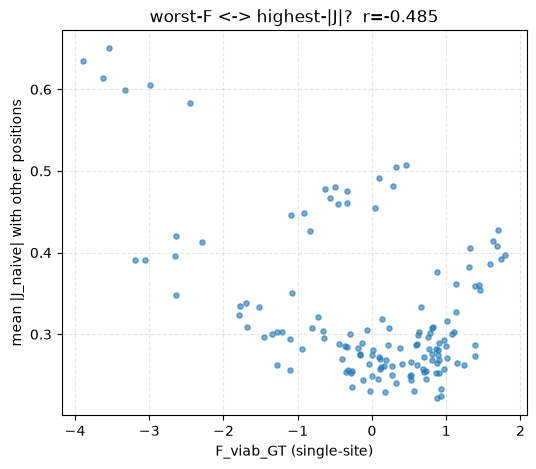

In [21]:
r_FJ_topK = pearson(F_part_bf[top_idx_bf], J_part_bf[top_idx_bf])
r_FJ_rand = pearson(F_part_bf, J_part_bf)
print(f"Pearson r(F_part, J_part) within the top-{TOP_K_BF}: {r_FJ_topK:+.3f}   "
      f"(full {N_BF:,}-sample background: {r_FJ_rand:+.3f})")

# Per-(amino acid, position) cell: does a worse F go with a larger mean |J| it carries with
# other positions? Same diagnostic as AAV_MLP_weights_recovery.ipynb's plot_F_vs_J_magnitude,
# recomputed here directly on the NAIVE F_viab_GT/J_naive_before.
off_diag_mask = ~np.eye(num_positions, dtype=bool)
J_mag_cell = np.zeros((num_amino_acids, num_positions))
for a in range(num_amino_acids):
    for i in range(num_positions):
        J_mag_cell[a, i] = np.mean(np.abs(J_naive_before[i][off_diag_mask[i]][:, a, :]))
r_cellwise = pearson(F_viab_GT.ravel(), J_mag_cell.ravel())
print(f"Pearson r(F_viab_GT, mean |J_naive| carried with other positions), per (aa, position) cell: {r_cellwise:+.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(F_viab_GT.ravel(), J_mag_cell.ravel(), s=14, alpha=0.6)
ax.set_xlabel("F_viab_GT (single-site)"); ax.set_ylabel("mean |J_naive| with other positions")
ax.set_title(f"worst-F <-> highest-|J|?  r={r_cellwise:.3f}")
ax.grid(True, linestyle="--", alpha=0.3)
plt.show()


In [22]:
j_flat    = J_naive_before[off_diag_mask].ravel()
se_flat   = J_naive_se[off_diag_mask].ravel()
supp_flat = support_naive[off_diag_mask].ravel()
finite_se = np.isfinite(se_flat)

print(f"{finite_se.sum():,}/{se_flat.size:,} off-diagonal cells have an estimable SE (n>=2 "
      f"real supporting sequences); the rest (n=0 or n=1) have no way to estimate their own "
      f"noise and are fully attenuated below.")
print(f"Pearson r(support_naive, J_se) across cells with an estimable SE: "
      f"{pearson(supp_flat[finite_se].astype(float), se_flat[finite_se]):+.3f}  "
      f"(negative = less real-data support -> noisier)")
print(f"Median |J_naive|/J_se (signal-to-noise) among those cells: "
      f"{np.median(np.abs(j_flat[finite_se]) / se_flat[finite_se]):.2f}")

_, _, se_top = dominant_pair_support(seq_bf[top_idx_bf], J_naive_before, support_naive, J_se=J_naive_se)
finite_se_top = np.isfinite(se_top)
print(f"Median J_se AT the top-{TOP_K_BF} variants' dominant cell "
      f"({finite_se_top.sum()}/{TOP_K_BF} have an estimable SE): "
      f"{np.median(se_top[finite_se_top]):.4f}   "
      f"(vs a typical off-diagonal cell: {np.median(se_flat[finite_se]):.4f})")
print(f"Median |J_naive|/J_se AT that same dominant cell: "
      f"{np.median(absJ_top[finite_se_top] / se_top[finite_se_top]):.2f}   "
      f"(vs the overall median ratio: {np.median(np.abs(j_flat[finite_se]) / se_flat[finite_se]):.2f})")


16,800/16,800 off-diagonal cells have an estimable SE (n>=2 real supporting sequences); the rest (n=0 or n=1) have no way to estimate their own noise and are fully attenuated below.


Pearson r(support_naive, J_se) across cells with an estimable SE: +0.122  (negative = less real-data support -> noisier)
Median |J_naive|/J_se (signal-to-noise) among those cells: 0.88
Median J_se AT the top-500 variants' dominant cell (500/500 have an estimable SE): 0.2909   (vs a typical off-diagonal cell: 0.2984)
Median |J_naive|/J_se AT that same dominant cell: 3.13   (vs the overall median ratio: 0.88)


#### L2 penalization = closed-form ridge / empirical-Bayes shrinkage, weighted by each cell's own noise

Each `J_naive_raw[i, j, a, b]` is the mean `target` of the `n` real `aav9.csv` sequences that
actually carry (a at i) AND (b at j), with standard error `J_se[i, j, a, b] =
std(target, ddof=1)/sqrt(n)` measured directly from those same real sequences -- classical
sampling theory, no model, no probing, no synthetic backgrounds. Solving the L2-penalized
least-squares problem

`min_mu  sum_m (x_m - mu)^2  +  lambda * mu^2`

has the closed form `mu_hat = x_bar * n / (n + lambda)`. Writing `lambda = J_se^2 / tau^2` for
a shared "true signal" variance `tau^2` (constant across cells) turns this into

`J_smooth[i, j, a, b] = J_naive_raw[i, j, a, b] * tau^2 / (tau^2 + J_se[i, j, a, b]^2)`

the standard James-Stein / empirical-Bayes ridge shrinkage: cells backed by MANY real
sequences (small `J_se`) are barely shrunk, cells backed by FEW real sequences (large `J_se`,
including the `n<2` cells above, at `J_se=+inf`) are shrunk hard toward 0.
`tau^2` is estimated by method of moments: noise always inflates apparent variance
(`Var(J_naive_raw) = tau^2 + E[J_se^2]`), so `tau^2 = max(0, Var(J_naive_raw) - mean(J_se^2))`,
computed on the best-supported cells only (below).

In [23]:
# Robust tau^2: estimate the "genuine signal" variance from the best-supported (lowest-SE)
# quartile of cells with an estimable SE only (n>=2). Cells with n<2 (SE=+inf) contribute no
# information about the true signal variance and are excluded from the tau^2 estimate itself
# -- but are still fully attenuated to 0 by the formula below (tau^2/(tau^2+inf) = 0).
se_flat_all  = J_naive_se[off_diag_mask].ravel()
j_flat_all   = J_naive_before[off_diag_mask].ravel()
finite_mask  = np.isfinite(se_flat_all)
se_q25       = np.quantile(se_flat_all[finite_mask], 0.25)
reliable     = finite_mask & (se_flat_all <= se_q25)
var_reliable = np.var(j_flat_all[reliable])
mse_reliable = np.mean(se_flat_all[reliable] ** 2)
tau2         = max(0.0, var_reliable - mse_reliable)

# REG_STRENGTH tunes how aggressive the attenuation is, on top of the data-driven tau^2/SE
# estimate above. Recall (3c markdown) shrink_factor = tau^2 / (tau^2 + lambda) with
# lambda = J_se^2 / tau^2 in the "n/(n+lambda)" reading -- equivalently, shrink_factor =
# tau^2 / (tau^2 + REG_STRENGTH * J_se^2) scales lambda by REG_STRENGTH directly:
#   REG_STRENGTH = 1  -> unchanged (the data-driven estimate as-is)
#   REG_STRENGTH > 1  -> MORE attenuation (every cell's own noise counted as REG_STRENGTH x
#                        larger than measured, so more of J gets pulled toward 0)
#   REG_STRENGTH < 1  -> LESS attenuation (closer to the raw, un-shrunk J_naive_before)
#
# PROJECT DECISION (2026-08-13): REG_STRENGTH=5 is the canonical value exported below and
# used by every other notebook that loads F_viab/J_viab via initialize_weights.py. The
# REG_STRENGTH sweep two cells above shows this does NOT yet fully eliminate the pathological
# combinatorial-extrapolation optimum (worst-of-top-500 vs. model_mlp: 0.0% at reg=5, only
# reg=10 clears it) -- kept at 5 anyway by deliberate choice, not because it's the value that
# resolved that check.
REG_STRENGTH = 5.0

shrink_factor = np.where(np.isfinite(J_naive_se), tau2 / (tau2 + REG_STRENGTH * J_naive_se ** 2), 0.0)
J_smooth = J_naive_before * shrink_factor
J_smooth[~off_diag_mask] = 0.0  # keep the diagonal convention (no self-interaction)

shrink_offdiag = shrink_factor[off_diag_mask]  # (42, 20, 20) -- off_diag_mask (L, L) can only
                                                 # boolean-index J's leading 2 dims directly;
                                                 # combining it with a (L, L, A, A) mask via &
                                                 # needs matching ranks first, so index in two
                                                 # steps instead.
print(f"tau^2 estimated on the {reliable.sum():,} best-supported cells (SE <= {se_q25:.3f}, "
      f"25th pct among estimable cells): Var={var_reliable:.4f}  mean(SE^2)={mse_reliable:.4f}  "
      f"=> tau^2={tau2:.4f}   (REG_STRENGTH={REG_STRENGTH})")
print(f"Median attenuation factor: overall (estimable cells)="
      f"{np.median(shrink_offdiag[np.isfinite(J_naive_se[off_diag_mask])]):.3f}   "
      f"at top-{TOP_K_BF} variants' dominant cell="
      f"{np.median(np.where(np.isfinite(se_top), tau2 / (tau2 + REG_STRENGTH * se_top ** 2), 0.0)):.3f}")
print(f"|J| reduced from mean={np.mean(np.abs(j_flat_all)):.4f} "
      f"to mean={np.mean(np.abs(J_smooth[off_diag_mask])):.4f} "
      f"({100 * (1 - np.mean(np.abs(J_smooth[off_diag_mask])) / np.mean(np.abs(j_flat_all))):.1f}% attenuation)")

J_naive_final = J_smooth  # the credible, attenuated GT -- exported below.


tau^2 estimated on the 4,200 best-supported cells (SE <= 0.271, 25th pct among estimable cells): Var=0.3165  mean(SE^2)=0.0488  => tau^2=0.2676   (REG_STRENGTH=5.0)
Median attenuation factor: overall (estimable cells)=0.375   at top-500 variants' dominant cell=0.387
|J| reduced from mean=0.3266 to mean=0.1390 (57.4% attenuation)


In [24]:
F_part_bf2, J_part_bf2, total_bf2 = score_FJ(seq_bf, F_viab_GT, J_naive_final, baseline_bf)
top_idx_bf2 = np.argsort(-total_bf2)[:TOP_K_BF]

print(f"Same brute-force top-{TOP_K_BF} check, AFTER attenuation:")
print(f"  top-{TOP_K_BF}      F_part: mean={F_part_bf2[top_idx_bf2].mean():+.2f}   "
      f"J_part: mean={J_part_bf2[top_idx_bf2].mean():+.2f}   "
      f"({(J_part_bf2[top_idx_bf2] > 0).mean()*100:.1f}% positive J_part, was "
      f"{(J_part_bf[top_idx_bf] > 0).mean()*100:.1f}% before)")


Same brute-force top-500 check, AFTER attenuation:
  top-500      F_part: mean=+7.00   J_part: mean=+1.03   (95.4% positive J_part, was 100.0% before)


#### Before / after: individual `J` matrices for real top variants

Reusing `AAV_MLP_weights_recovery.ipynb`'s per-variant `J` grid visual (`plot_J_grid_for_variant`):
one (amino acid x amino acid) heatmap per position pair, with the cell this specific sequence
actually uses boxed in red. Shown for the top real held-out variants (`idx_test`, by actual
measured `target`) -- `J_naive_before` (naive retrieval, un-attenuated) vs `J_naive_final`
(after credibility-weighted attenuation).

real top-variant #1: VAVRQQG   target=7.473


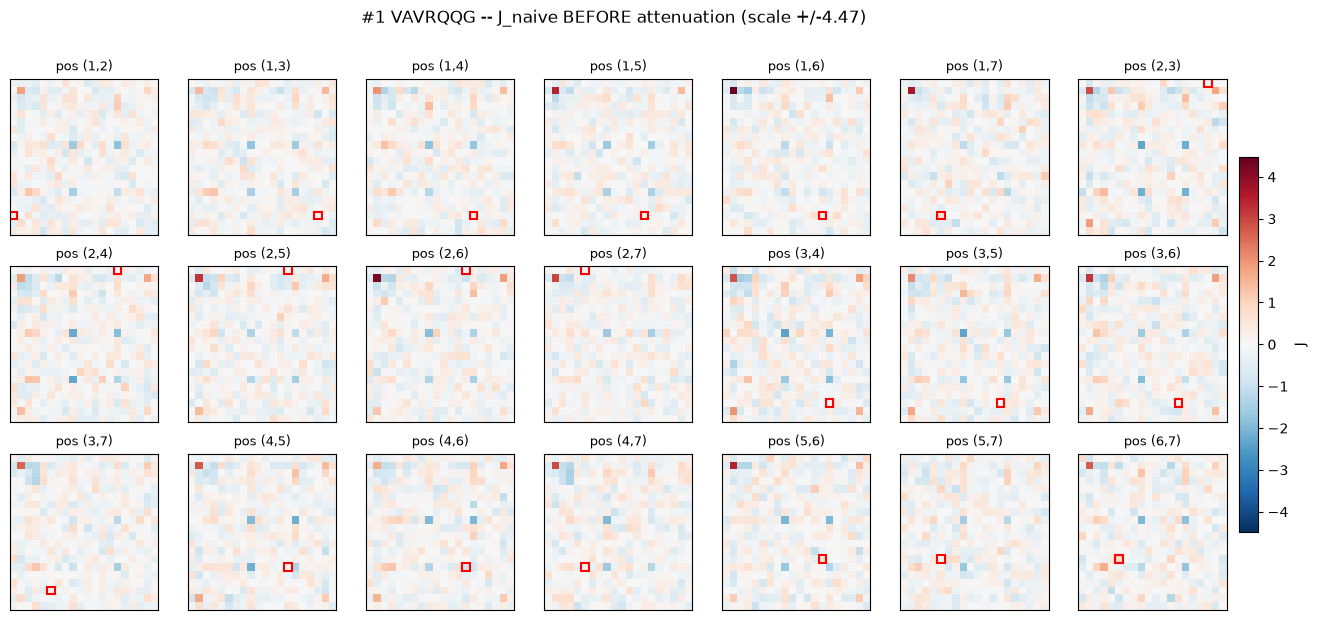

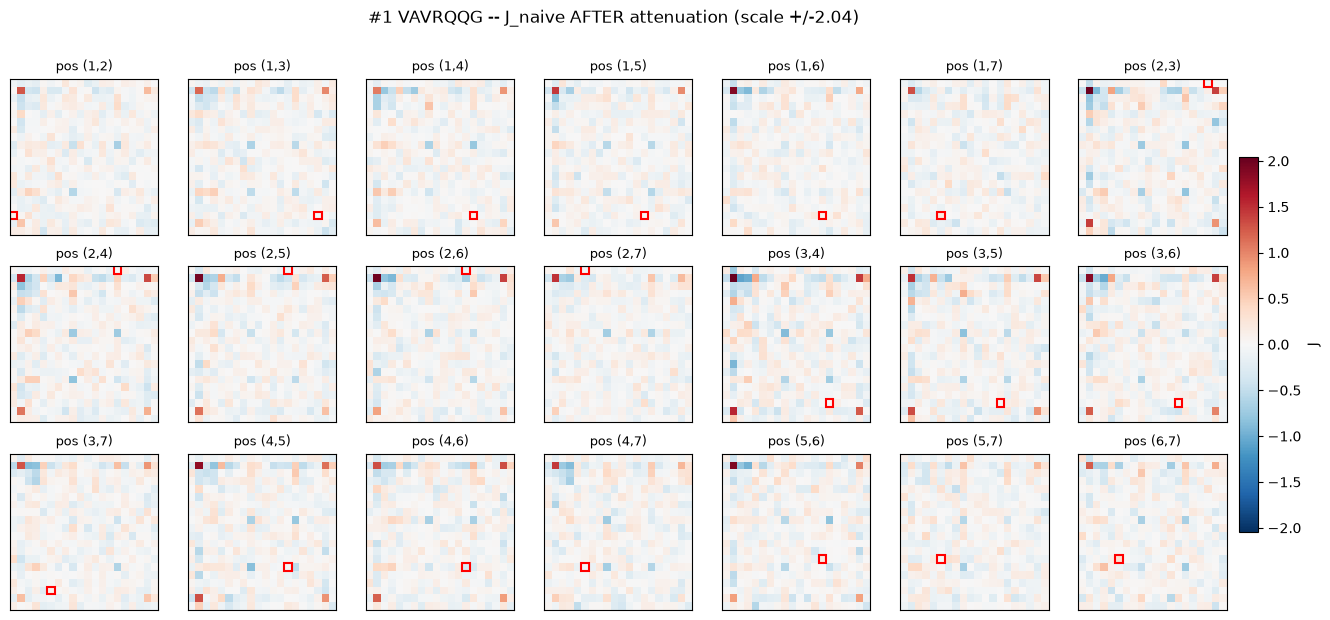

real top-variant #2: PPPVASV   target=7.473


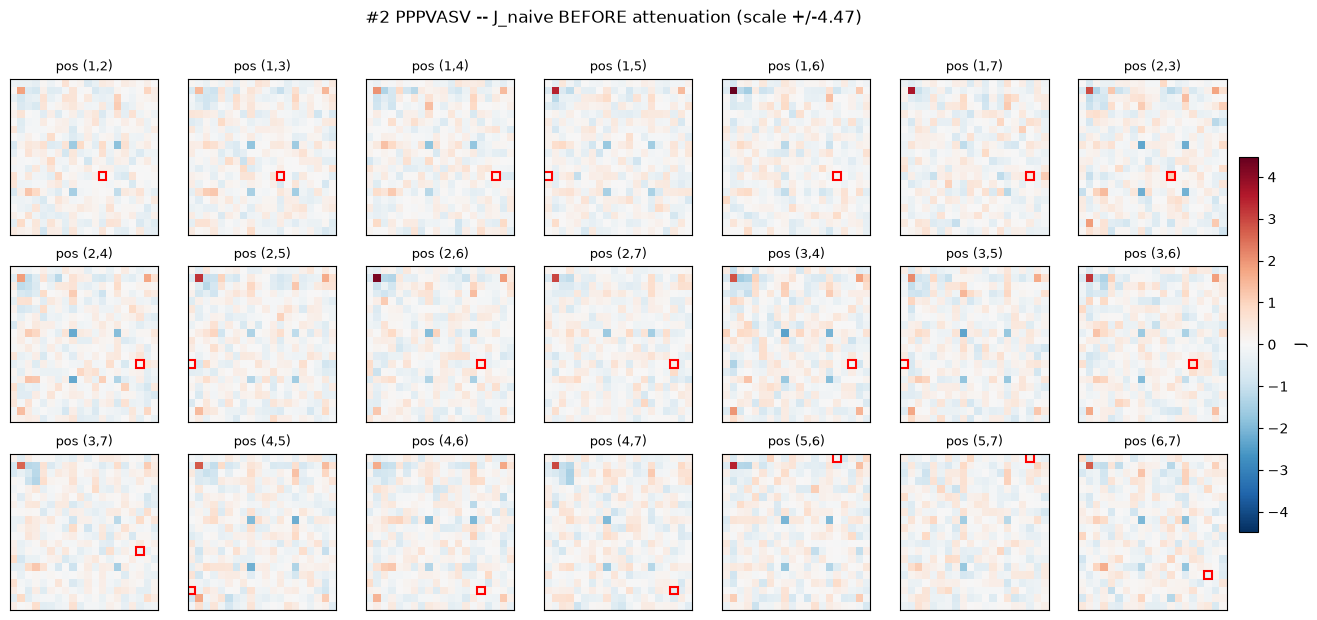

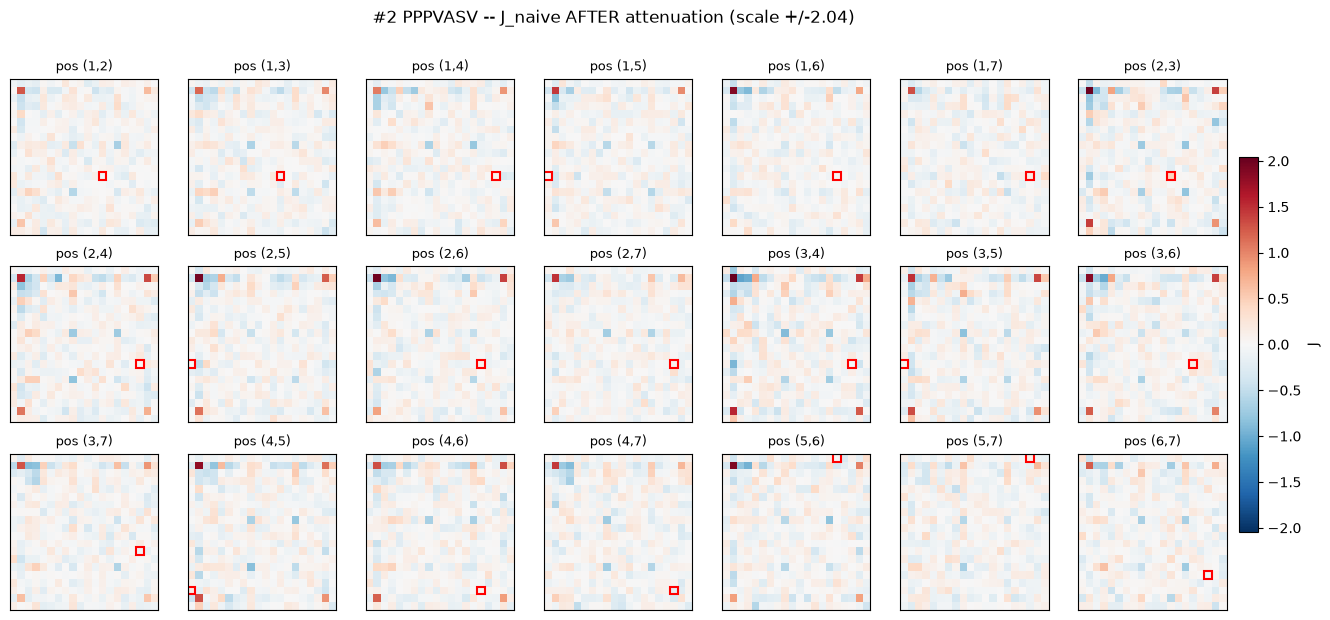

In [25]:
from matplotlib.patches import Rectangle

def plot_J_grid_for_variant(J, seq, pairs=None, title=None, cmap="RdBu_r", ncols=7, vmax=None):
    """Adapted from AAV_MLP_weights_recovery.ipynb: grid of every pairwise J[i, j] (A, A)
    heatmap, with the (aa at i, aa at j) cell THIS sequence uses boxed in red."""
    L = len(seq)
    if pairs is None:
        pairs = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n     = len(pairs)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    vmax  = vmax if vmax is not None else np.nanmax(np.abs(J))

    fig, axes = plt.subplots(nrows, ncols, figsize=(2.3 * ncols, 2.3 * nrows), squeeze=False)
    for k, (i, j) in enumerate(pairs):
        ax = axes[k // ncols, k % ncols]
        im = ax.imshow(J[i, j], aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.add_patch(Rectangle((int(seq[j]) - 0.5, int(seq[i]) - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=1.5))
        ax.set_title(f"pos ({i + 1},{j + 1})", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")
    if title:
        fig.suptitle(title)
    fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, label="J")
    return fig


N_SHOW = 2
order_real_top = np.argsort(-y_test)[:N_SHOW]
# Independent color scale per plot: after attenuation |J| is much smaller on average (see
# above), so sharing the BEFORE scale would squash the AFTER grid into a narrow pale band and
# hide its own (now much smaller) weight distribution. Each grid is scaled to its own max,
# with the actual +/- scale printed in the title so the two are never mistaken for the same
# units.
vmax_before = np.nanmax(np.abs(J_naive_before))
vmax_after  = np.nanmax(np.abs(J_naive_final))

for rank, oi in enumerate(order_real_top, start=1):
    gi      = idx_test[oi]
    seq_idx = seq_matrix[gi]
    seq_str = df["sequence"].iloc[gi]
    print(f"real top-variant #{rank}: {seq_str}   target={df['target'].iloc[gi]:.3f}")

    plot_J_grid_for_variant(J_naive_before, seq_idx,
                             title=f"#{rank} {seq_str} -- J_naive BEFORE attenuation (scale +/-{vmax_before:.2f})",
                             vmax=vmax_before)
    plt.show()
    plot_J_grid_for_variant(J_naive_final, seq_idx,
                             title=f"#{rank} {seq_str} -- J_naive AFTER attenuation (scale +/-{vmax_after:.2f})",
                             vmax=vmax_after)
    plt.show()


In [26]:
# Export F_viab and J_viab (naive retrieval + L2/credibility attenuation, see 3c) for use
# elsewhere in the project (Modelization_V1/lib/initialize_weights.py), so simulations can be
# seeded with REAL AAV9-derived weights instead of synthetic random ones. Saved into lib/,
# alongside sequence_classesV1.py -- .npy files are gitignored (a derived artifact, not
# source), so just re-run this cell any time aav9.csv changes to refresh both.
#
# DELIBERATELY NOT model-derived: neither model_mlp's probed F_mlp/J_mlp nor model_pair's
# directly-fit parameters are used here -- an MLP-derived J can extrapolate into (i, j, a, b)
# combinations barely seen in the real data, producing large but not-credible couplings (3c).
# F is the plain naive per-position mean (F_viab_GT, ~490 real sequences of support per cell
# on average -- no attenuation needed); J is the naive per-pair mean (J_naive_raw) with
# credibility-weighted L2 attenuation applied (J_naive_final), zeroing out cells with too
# little real support to trust rather than extrapolating past them.
#
# FIXED (2026-08-13): this used to save to os.path.join("..", "..", ...), i.e. straight into
# Modelization_V1/ -- ONE level short of lib/, where initialize_weights.py actually loads
# from (AAV9_F_VIAB_PATH = os.path.join(_HERE, "aav9_F_viab_mlp.npy") with _HERE = lib/).
# The two paths had silently diverged. Fixed to point at lib/ explicitly.
F_VIAB_EXPORT_PATH = os.path.join("..", "..", "..", "lib", "aav9_F_viab_mlp.npy")
J_VIAB_EXPORT_PATH = os.path.join("..", "..", "..", "lib", "aav9_J_viab_mlp.npy")

np.save(F_VIAB_EXPORT_PATH, F_viab_GT.astype(np.float32))
np.save(J_VIAB_EXPORT_PATH, np.nan_to_num(J_naive_final, nan=0.0).astype(np.float32))

print(f"Saved F_viab_GT {F_viab_GT.shape} to {os.path.abspath(F_VIAB_EXPORT_PATH)}")
print(f"Saved J_naive_final {J_naive_final.shape} to {os.path.abspath(J_VIAB_EXPORT_PATH)}")


Saved F_viab_GT (20, 7) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/lib/aav9_F_viab_mlp.npy
Saved J_naive_final (7, 7, 20, 20) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/lib/aav9_J_viab_mlp.npy


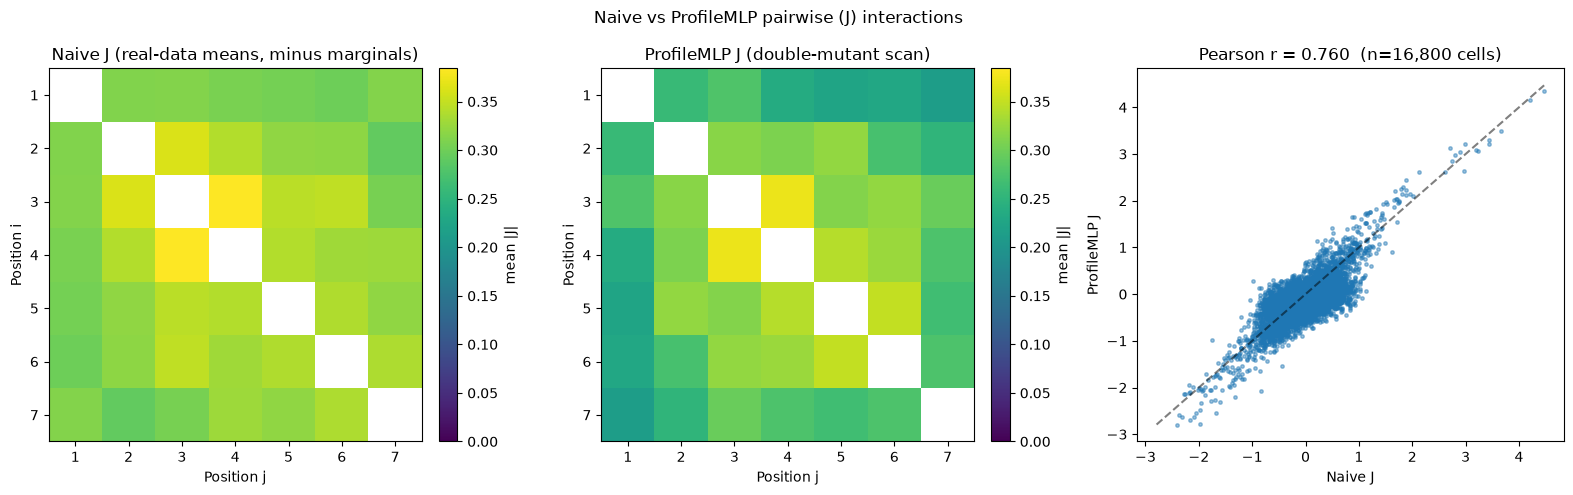

In [27]:
def coupling_strength(J):
    """(L, L, A, A) -> (L, L) mean |J_ij(a, b)| per position pair; NaN cells (no/too little
    support) are skipped rather than propagated, so one sparse cell doesn't NaN out its
    whole (i, j) pair. The diagonal (i == j, "interaction with itself") is left NaN directly,
    without ever calling nanmean on an all-NaN slice (which numpy would warn about)."""
    L = J.shape[0]
    off_diag = ~np.eye(L, dtype=bool)
    strength = np.full((L, L), np.nan)
    strength[off_diag] = np.nanmean(np.abs(J[off_diag]), axis=(1, 2))
    return strength

strength_naive = coupling_strength(J_naive)
strength_mlp   = coupling_strength(J_mlp)
vmax_strength  = np.nanmax([strength_naive, strength_mlp])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, S, title in [(axes[0], strength_naive, "Naive J (real-data means, minus marginals)"),
                      (axes[1], strength_mlp,   "ProfileMLP J (double-mutant scan)")]:
    im = ax.imshow(S, cmap="viridis", vmin=0, vmax=vmax_strength)
    ax.set_xlabel("Position j")
    ax.set_ylabel("Position i")
    ax.set_xticks(range(num_positions)); ax.set_xticklabels(range(1, num_positions + 1))
    ax.set_yticks(range(num_positions)); ax.set_yticklabels(range(1, num_positions + 1))
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="mean |J|", fraction=0.046, pad=0.04)

# Raw-entry scatter, restricted to cells where the naive estimate actually had enough
# supporting sequences (min_support) to be trustworthy -- ProfileMLP's J is defined
# everywhere off-diagonal, but only compared where there's a real naive value to check it
# against.
mask_support = ~np.isnan(J_naive)
j_naive_flat = J_naive[mask_support]
j_mlp_flat   = J_mlp[mask_support]
r_J = pearson(j_naive_flat, j_mlp_flat)

axes[2].scatter(j_naive_flat, j_mlp_flat, s=6, alpha=0.25)
lims = [min(j_naive_flat.min(), j_mlp_flat.min()), max(j_naive_flat.max(), j_mlp_flat.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive J")
axes[2].set_ylabel("ProfileMLP J")
axes[2].set_title(f"Pearson r = {r_J:.3f}  (n={mask_support.sum():,} cells)")

fig.suptitle("Naive vs ProfileMLP pairwise (J) interactions")
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Top <b>5,000</b> (not 500) sequences over the <b>full</b> real aav9.csv (all 68,776 rows), ranked by <code>model_mlp</code>'s <b>predicted</b> <code>total_score</code> — not the measured target, and not restricted to held-out data. Don't confuse this K=5000 predicted-ranking set (full library) with the K=500 true-target set used later in this notebook (held-out only).
</div>

### 4. Ranking real sequences: total / F / J score breakdown

For every real sequence in `aav9.csv`, decompose the trained `model_mlp`'s score into the
pieces recovered above:

- **`total_score`** — the model's own prediction for that exact sequence (`model_mlp` forward
  pass on its one-hot encoding) — the full black-box score, all orders included.
- **`F_score`** — the single-site (additive) contribution only: `sum_i F_viab[seq_i, i]`,
  using the `F_mlp` profile recovered by the single-mutant scan in section 3.
- **`J_score`** — the pairwise (epistatic) contribution only: `sum_{i<j} J_viab[i, j, seq_i,
  seq_j]`, using the `J_mlp` tensor recovered by the double-mutant scan in section 3b.

`total_score ≈ mean_score + F_score + J_score + (higher-order terms neither scan captures)`.
Sorted by `total_score`, kept to the top 5,000 real sequences.


In [28]:
def batched_predict(model, X_oh, batch_size=8192):
    chunks = []
    for start in range(0, X_oh.shape[0], batch_size):
        chunk = jnp.asarray(X_oh[start : start + batch_size])
        chunks.append(np.asarray(predict_scores(model, chunk)))
    return np.concatenate(chunks)

total_score = batched_predict(model_mlp, seq_oh)

F_score = F_mlp[seq_matrix, np.arange(num_positions)].sum(axis=1)

J_score = np.zeros(len(df), dtype=np.float32)
for i in range(num_positions):
    for j in range(i + 1, num_positions):
        J_score += J_mlp[i, j, seq_matrix[:, i], seq_matrix[:, j]]

print(f"total_score: mean={total_score.mean():.3f}  std={total_score.std():.3f}")
print(f"F_score:     mean={F_score.mean():.3f}  std={F_score.std():.3f}")
print(f"J_score:     mean={J_score.mean():.3f}  std={J_score.std():.3f}")


total_score: mean=-3.934  std=4.237
F_score:     mean=0.345  std=3.522
J_score:     mean=-2.367  std=1.866


In [29]:
scores_df = pd.DataFrame({
    "sequence": df["sequence"].to_numpy(),
    "total_score": total_score,
    "F_score": F_score,
    "J_score": J_score,
    "target": target,
})

top5000_df = scores_df.sort_values("total_score", ascending=False).head(5000).reset_index(drop=True)
top5000_df


,sequence,total_score,F_score,J_score,target
0,TQNLSKS,5.587405,4.815166,0.097197,3.621034
1,NANKAGM,5.549398,5.825918,-0.295328,5.084973
2,YAASSKT,5.536659,4.617420,-0.356203,6.008946
3,VQGKFAG,5.485497,3.238344,0.362531,5.799932
4,TAVKMGA,5.333708,4.455188,-0.328328,3.518347
...,...,...,...,...,...
4995,QPDSTGK,2.221305,6.190036,-2.128164,0.680183
4996,KEHSGER,2.221147,4.913407,-2.485458,1.896241
4997,TSTNLTG,2.221126,5.705916,-0.771287,2.839461
4998,REPGARV,2.220977,4.305140,-2.387767,-0.512513


### 5. Does the credible GT correctly place the REAL best variants? (exhaustive, no sampling, no model)

Direct continuation of 3c: exhaustively scores EVERY one of the `20**7 ~= 1.28e9` possible
sequences with the credible, naive+attenuated `F_viab_GT`/`J_naive_final` -- no MLP, no
separately-trained model, just `gather + sum` (cheap enough to brute-force on GPU in a couple
of minutes, same `brute_force_top_k` recipe as `MLP_for_anticorrelated_weights.ipynb`) -- and
checks where the REAL top-500 variants (by actual measured `target`, held-out test split) and
the TRUE global-optimum variants (found by the same exhaustive scan) land relative to a large
random background.

In [30]:
def compute_score_array(seq, F, J, L=num_positions):
    """Same formula as score_FJ's total (3c), decoupled from a fixed seq array so it can be
    applied inside a jitted chunked scan. Same convention as MLP_for_anticorrelated_weights.ipynb's
    compute_score_array / sequence_classesV1.Protocol.compute_score."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _score_chunk(idx, F, J, L=num_positions, A=num_amino_acids):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=500, chunk_size=20_000_000, L=num_positions, A=num_amino_acids):
    """Exhaustively scores EVERY possible sequence (A**L of them) against F/J and keeps a
    running top-k, in GPU chunks -- same recipe as MLP_for_anticorrelated_weights.ipynb's
    brute_force_top_k. A**L = 20**7 ~= 1.28e9 is small enough to brute-force directly."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan (credible GT)"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, jnp.asarray(F), jnp.asarray(J))

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


TOP_N = 500
best_seqs_true, best_scores_true = brute_force_top_k(F_viab_GT, J_naive_final, k=TOP_N)

# Real, measured top-500 (held-out test split, by actual target) scored with the SAME
# credible GT, for comparison against a large random background.
top_gt_500_ordered = np.argsort(-y_test)[:TOP_N]
real_top500_seqs   = seq_matrix[idx_test[top_gt_500_ordered]]
real_top500_scores = np.asarray(compute_score_array(jnp.asarray(real_top500_seqs), F_viab_GT, J_naive_final))

print(f"TRUE global-optimum score (exhaustive, credible GT): {best_scores_true[0]:.2f}")
print(f"Best of the REAL top-{TOP_N} (held-out, measured target) under the same GT: {real_top500_scores.max():.2f}")


brute-force scan (credible GT):   0%|          | 0/64 [00:00<?, ?it/s]

brute-force scan (credible GT):   2%|▏         | 1/64 [00:01<01:04,  1.02s/it]

brute-force scan (credible GT):   6%|▋         | 4/64 [00:01<00:13,  4.33it/s]

brute-force scan (credible GT):   9%|▉         | 6/64 [00:01<00:09,  6.41it/s]

brute-force scan (credible GT):  12%|█▎        | 8/64 [00:01<00:06,  8.39it/s]

...

brute-force scan (credible GT):  80%|███████▉  | 51/64 [00:03<00:00, 30.32it/s]

brute-force scan (credible GT):  88%|████████▊ | 56/64 [00:03<00:00, 34.01it/s]

brute-force scan (credible GT):  95%|█████████▌| 61/64 [00:03<00:00, 37.21it/s]

brute-force scan (credible GT): 100%|██████████| 64/64 [00:03<00:00, 18.31it/s]

TRUE global-optimum score (exhaustive, credible GT): 9.88
Best of the REAL top-500 (held-out, measured target) under the same GT: 7.80


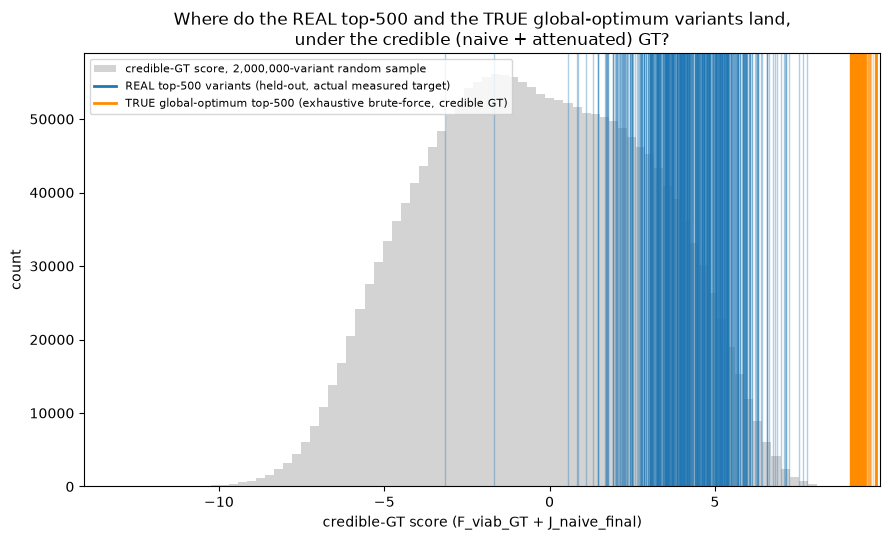

The REAL top-500's WORST score still beats 22.8% of the random background under the credible GT.


In [31]:
rng_hist = np.random.default_rng(1)
N_HIST   = 2_000_000
seq_hist = rng_hist.integers(0, num_amino_acids, size=(N_HIST, num_positions))
hist_scores = np.asarray(compute_score_array(jnp.asarray(seq_hist), F_viab_GT, J_naive_final))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(hist_scores, bins=80, color="lightgray",
        label=f"credible-GT score, {N_HIST:,}-variant random sample")
for v in real_top500_scores:
    ax.axvline(v, color="tab:blue", alpha=0.35, lw=1)
ax.axvline(real_top500_scores[0], color="tab:blue", lw=2,
           label=f"REAL top-{TOP_N} variants (held-out, actual measured target)")
for v in best_scores_true:
    ax.axvline(v, color="darkorange", alpha=0.35, lw=1)
ax.axvline(best_scores_true[0], color="darkorange", lw=2,
           label=f"TRUE global-optimum top-{TOP_N} (exhaustive brute-force, credible GT)")
ax.set_xlabel("credible-GT score (F_viab_GT + J_naive_final)")
ax.set_ylabel("count")
ax.set_title(f"Where do the REAL top-{TOP_N} and the TRUE global-optimum variants land,\n"
             f"under the credible (naive + attenuated) GT?")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

pct_real = 100 * (hist_scores < real_top500_scores.min()).mean()
print(f"The REAL top-{TOP_N}'s WORST score still beats {pct_real:.1f}% of the random background "
      f"under the credible GT.")


#### Cross-check: does the credible GT's global optimum also look good to `model_mlp`?

Same idea, but now scored by `model_mlp` (section 3) instead of the credible GT itself.
`model_mlp` is trained directly on the real `target` (log enrichment) by MSE, no Potts
(additive + pairwise) assumption at all -- so its raw output already IS a predicted log
enrichment value. If the sequences the credible GT considers "best" (`best_seqs_true`,
found by exhaustive brute-force above) also get a high predicted log enrichment from this
completely independent model, that's real cross-validation of the GT's notion of "best".

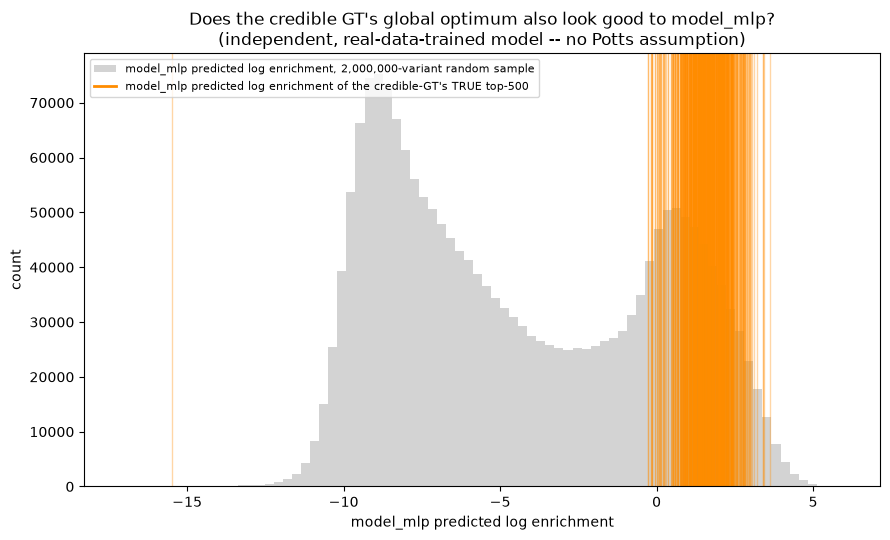

The credible-GT's TRUE top-500's WORST model_mlp-predicted log enrichment still beats 0.0% of the random background.


In [32]:
seq_hist_oh       = np.eye(num_amino_acids, dtype=np.float32)[seq_hist].reshape(len(seq_hist), -1)
best_seqs_true_oh = np.eye(num_amino_acids, dtype=np.float32)[best_seqs_true].reshape(len(best_seqs_true), -1)

pred_log_enr_hist = batched_predict(model_mlp, seq_hist_oh)
pred_log_enr_best = batched_predict(model_mlp, best_seqs_true_oh)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(pred_log_enr_hist, bins=80, color="lightgray",
        label=f"model_mlp predicted log enrichment, {N_HIST:,}-variant random sample")
for v in pred_log_enr_best:
    ax.axvline(v, color="darkorange", alpha=0.35, lw=1)
ax.axvline(pred_log_enr_best[0], color="darkorange", lw=2,
           label=f"model_mlp predicted log enrichment of the credible-GT's TRUE top-{TOP_N}")
ax.set_xlabel("model_mlp predicted log enrichment")
ax.set_ylabel("count")
ax.set_title(f"Does the credible GT's global optimum also look good to model_mlp?\n"
             f"(independent, real-data-trained model -- no Potts assumption)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

pct_best = 100 * (pred_log_enr_hist < pred_log_enr_best.min()).mean()
print(f"The credible-GT's TRUE top-{TOP_N}'s WORST model_mlp-predicted log enrichment still beats "
      f"{pct_best:.1f}% of the random background.")


#### Same cross-check, swept over several `REG_STRENGTH` values

Re-derives `J` at each attenuation strength (reusing the already-estimated `tau2`/`J_naive_se`
from 3c -- only `REG_STRENGTH` changes), re-runs the exhaustive brute-force optimum for that
`J`, and re-scores it with `model_mlp`. The gray background (`pred_log_enr_hist`) doesn't
depend on `J` at all, so it's computed once and reused across every panel.

/tmp/ipykernel_2010593/1905322306.py:7: RuntimeWarning: invalid value encountered in multiply
  shrink_factor_r = np.where(np.isfinite(J_naive_se), tau2 / (tau2 + reg * J_naive_se ** 2), 0.0)


brute-force scan (credible GT):   0%|          | 0/64 [00:00<?, ?it/s]

brute-force scan (credible GT):   5%|▍         | 3/64 [00:00<00:02, 25.49it/s]

brute-force scan (credible GT):  11%|█         | 7/64 [00:00<00:01, 30.75it/s]

brute-force scan (credible GT):  19%|█▉        | 12/64 [00:00<00:01, 35.91it/s]

...

brute-force scan (credible GT):  72%|███████▏  | 46/64 [00:01<00:00, 44.92it/s]

brute-force scan (credible GT):  80%|███████▉  | 51/64 [00:01<00:00, 44.48it/s]

brute-force scan (credible GT):  88%|████████▊ | 56/64 [00:01<00:00, 44.68it/s]

brute-force scan (credible GT):  95%|█████████▌| 61/64 [00:01<00:00, 44.78it/s]

brute-force scan (credible GT): 100%|██████████| 64/64 [00:01<00:00, 44.98it/s]

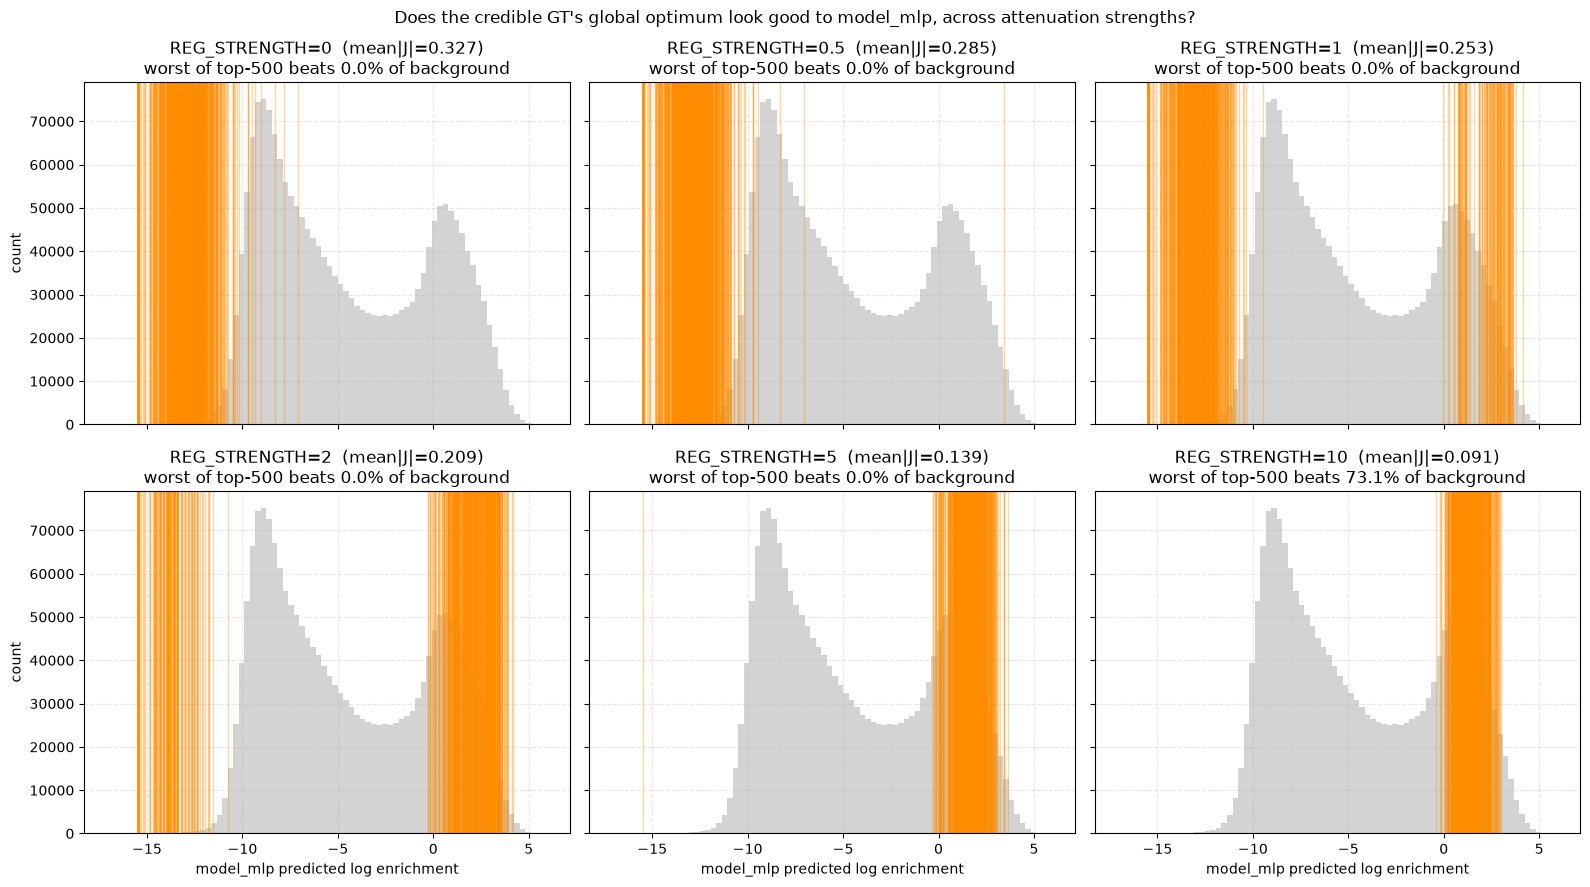

In [33]:
REG_VALUES = [0, 0.5, 1, 2, 5, 10]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, reg in zip(axes, REG_VALUES):
    shrink_factor_r = np.where(np.isfinite(J_naive_se), tau2 / (tau2 + reg * J_naive_se ** 2), 0.0)
    J_smooth_r = J_naive_before * shrink_factor_r
    J_smooth_r[~off_diag_mask] = 0.0

    best_seqs_r, best_scores_r = brute_force_top_k(F_viab_GT, J_smooth_r, k=TOP_N)
    best_seqs_r_oh       = np.eye(num_amino_acids, dtype=np.float32)[best_seqs_r].reshape(len(best_seqs_r), -1)
    pred_log_enr_best_r  = batched_predict(model_mlp, best_seqs_r_oh)
    mean_abs_J_r         = np.mean(np.abs(J_smooth_r[off_diag_mask]))
    pct_r                = 100 * (pred_log_enr_hist < pred_log_enr_best_r.min()).mean()

    ax.hist(pred_log_enr_hist, bins=80, color="lightgray")
    for v in pred_log_enr_best_r:
        ax.axvline(v, color="darkorange", alpha=0.35, lw=1)
    ax.axvline(pred_log_enr_best_r[0], color="darkorange", lw=2)
    ax.set_title(f"REG_STRENGTH={reg}  (mean|J|={mean_abs_J_r:.3f})\nworst of top-{TOP_N} beats {pct_r:.1f}% of background")
    ax.grid(True, linestyle="--", alpha=0.3)

for ax in axes[3:]:
    ax.set_xlabel("model_mlp predicted log enrichment")
for ax in (axes[0], axes[3]):
    ax.set_ylabel("count")

fig.suptitle("Does the credible GT's global optimum look good to model_mlp, across attenuation strengths?")
fig.tight_layout()
plt.show()


### 7. Direct profile model — construct the 140 weights directly

`ProfileMLP` above only reveals an effective `F` indirectly: it predicts a
scalar score through a black-box network, then `F` has to be pulled out
afterward with an expensive single-mutant scan. Here the model *is* the
`(num_amino_acids, num_positions)` profile matrix — no hidden layers, no
per-sequence nonlinearity: `score(seq) = bias + sum_i F[seq_i, i]`, the
exact functional form the naive profile already uses. It's trained with the
same nnx machinery as section 3 (`train_profile_mlp`, reused via its
`model=` warm-start argument), but the regression target for each sequence
is the score the **naive** profile (`F_viab_GT`) would predict for it — not
the noisy real `target` — so this checks whether gradient descent, using
this project's own training loop, converges to the same answer as the
closed-form per-position averaging.


# This does not work, we just find the noisy distribution, our goal is to predict the log enrichment of a variants base of his sequence, this deterministic model is easy to find by grandient descent but it is the noisy distribution, we don't want to recover this exact distribution.

In [34]:
raise SystemExit("checkpoint — stop ici")

SystemExit: checkpoint — stop ici

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [35]:
class DirectProfileModel(nnx.Module):
    """
    The model *is* the profile matrix: F (num_amino_acids, num_positions) and a scalar bias
    are the only trainable parameters, used exactly like Protocol.compute_score's profile
    term -- score(seq) = bias + sum_i F[seq_i, i]. `train`/`rngs` are accepted (unused) only
    so this matches ProfileMLP's call signature and can be dropped straight into train_step/
    eval_step/train_profile_mlp without changing any of that code.
    """

    def __init__(self, num_amino_acids: int, num_positions: int, *, rngs: nnx.Rngs):
        self.F    = nnx.Param(jax.random.normal(rngs.params(), (num_amino_acids, num_positions)) * 0.01)
        self.bias = nnx.Param(jnp.zeros(()))

    def __call__(self, x: jax.Array, *, train: bool = False, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        idx = x.astype(jnp.int32)
        return self.F[idx, jnp.arange(idx.shape[1])].sum(axis=1) + self.bias[...]


In [36]:
baseline   = target.mean()
naive_pred = baseline + F_viab_GT[seq_matrix, np.arange(num_positions)].sum(axis=1)
print(f"Pearson r (naive_pred vs real target): {pearson(target, naive_pred):.4f}")

# Same idx_train/idx_test/seq_matrix split as section 3's ProfileMLP -- only the regression
# target changes (naive_pred instead of the real target).
y_naive_train = naive_pred[idx_train]
y_naive_test  = naive_pred[idx_test]

Xtr_direct, ytr_direct, Xva_direct, yva_direct = split_train_val(X_mlp_train_full, y_naive_train, val_frac=0.15, seed=0)
print(f"DirectProfileModel -- train: {len(Xtr_direct):,}  val: {len(Xva_direct):,}  test: {len(X_mlp_test):,}")

model_direct_init = DirectProfileModel(num_amino_acids=num_amino_acids, num_positions=num_positions, rngs=nnx.Rngs(0))
model_direct, hist_direct = train_profile_mlp(
    Xtr_direct, ytr_direct, Xva_direct, yva_direct, model=model_direct_init, seed=0
)


Pearson r (naive_pred vs real target): 0.7788
DirectProfileModel -- train: 29,230  val: 5,158  test: 34,388


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:   0%|          | 1/300 [00:00<01:46,  2.81it/s]

Training ProfileMLP:   2%|▏         | 5/300 [00:00<00:23, 12.75it/s]

Training ProfileMLP:   3%|▎         | 9/300 [00:00<00:15, 18.97it/s]

...

Training ProfileMLP:  18%|█▊        | 55/300 [00:01<00:06, 37.73it/s]

Training ProfileMLP:  20%|█▉        | 59/300 [00:01<00:06, 36.44it/s]

Training ProfileMLP:  21%|██        | 63/300 [00:01<00:06, 34.27it/s]

Training ProfileMLP:  22%|██▏       | 65/300 [00:02<00:07, 31.87it/s]

Early stopping at epoch 65 (best val MSE=9.0562)


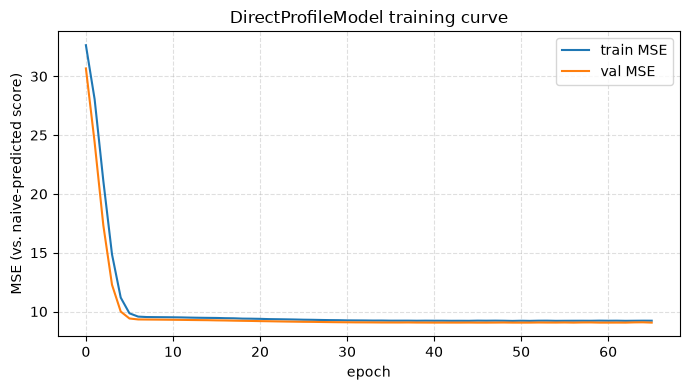

Pearson r (predictions vs. naive-predicted scores, held-out test): 0.1824
Pearson r (F_direct vs F_viab_GT, raw 140 weights): -0.3142


In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_direct["train_loss"], label="train MSE")
ax.plot(hist_direct["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (vs. naive-predicted score)")
ax.set_title("DirectProfileModel training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_test_direct = np.asarray(predict_scores(model_direct, jnp.asarray(X_mlp_test)))
print(f"Pearson r (predictions vs. naive-predicted scores, held-out test): {pearson(y_naive_test, pred_test_direct):.4f}")

F_direct = np.array(model_direct.F[...])
print(f"Pearson r (F_direct vs F_viab_GT, raw 140 weights): {pearson(F_viab_GT.ravel(), F_direct.ravel()):.4f}")


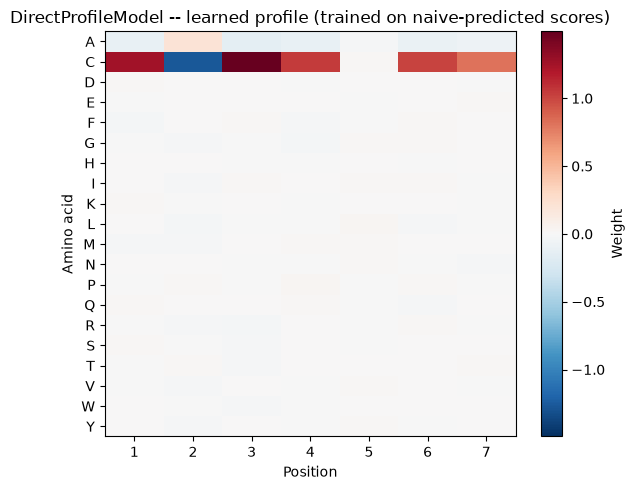

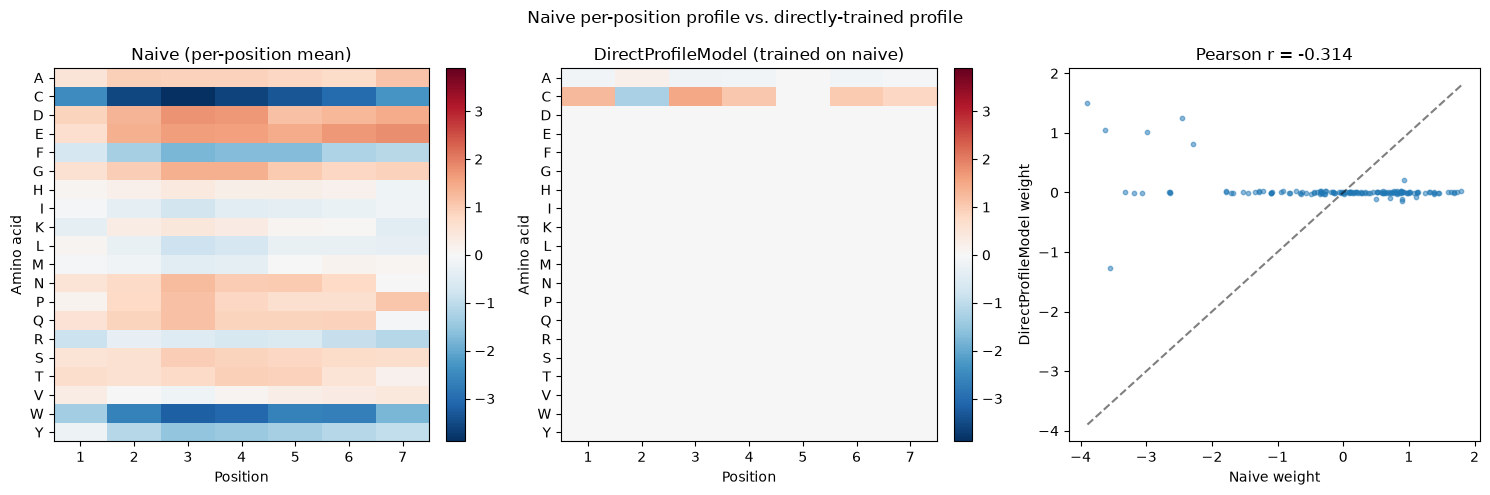

In [38]:
plot_teacher_weights(F_direct, title="DirectProfileModel -- learned profile (trained on naive-predicted scores)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = max(np.abs(F_viab_GT).max(), np.abs(F_direct).max())

for ax, F, title in [(axes[0], F_viab_GT, "Naive (per-position mean)"), (axes[1], F_direct, "DirectProfileModel (trained on naive)")]:
    im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amino acid")
    ax.set_xticks(range(num_positions))
    ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
    ax.set_yticks(range(num_amino_acids))
    ax.set_yticklabels(AA_LABELS)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

r_profiles = pearson(F_viab_GT.ravel(), F_direct.ravel())
axes[2].scatter(F_viab_GT.ravel(), F_direct.ravel(), s=10, alpha=0.5)
lims = [min(F_viab_GT.min(), F_direct.min()), max(F_viab_GT.max(), F_direct.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive weight")
axes[2].set_ylabel("DirectProfileModel weight")
axes[2].set_title(f"Pearson r = {r_profiles:.3f}")

fig.suptitle("Naive per-position profile vs. directly-trained profile")
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same held-out <code>idx_test</code> top-k population as the first box above, now applied to <code>DirectProfileModel</code> instead of <code>model_mlp</code>.
</div>

Pearson r (train): 0.1520
Pearson r (test):  0.1444

Held-out (test) top-k recovery vs the REAL target (not naive_pred):
  Top   1%   precision = 0.000   (random baseline = 0.010)
  Top   5%   precision = 0.038   (random baseline = 0.050)
  Top  10%   precision = 0.096   (random baseline = 0.100)
  Top  20%   precision = 0.220   (random baseline = 0.200)


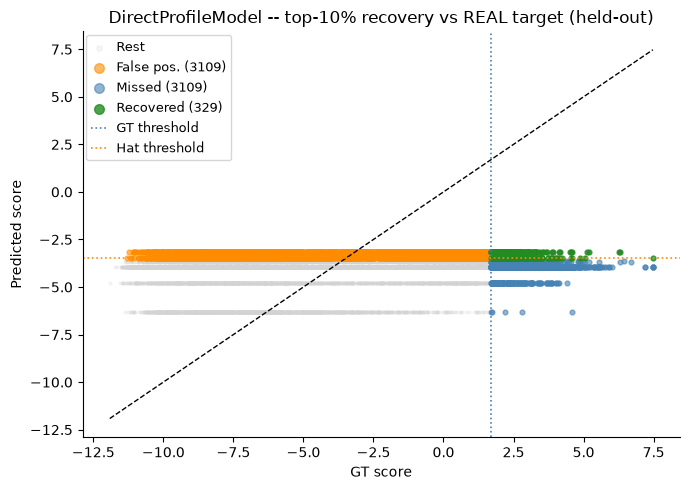

In [39]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)

pred_train_direct = np.asarray(predict_scores(model_direct, jnp.asarray(Xtr_mlp)))
pred_test_direct  = np.asarray(predict_scores(model_direct, jnp.asarray(X_mlp_test)))

print(f"Pearson r (train): {pearson(ytr_mlp, pred_train_direct):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test_direct):.4f}")
print()
print("Held-out (test) top-k recovery vs the REAL target (not naive_pred):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test_direct, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_test, pred_test_direct, k_frac=0.10, title="DirectProfileModel -- top-10% recovery vs REAL target (held-out)")
plt.show()


**Why MSE → 0 during training:** `naive_pred` is, by construction, exactly
`bias + sum_i F[seq_i, i]` — the same functional form `DirectProfileModel`
uses. There's no noise in that target: it's a deterministic linear function
of the 140+1 unknowns, and `DirectProfileModel` has exactly those 140+1
unknowns as its only parameters. MSE is a convex (quadratic) function of a
linear model's own parameters, and a zero-residual solution provably exists
(`F = F_viab_GT`, `bias = baseline`) — so Adam just has to find that global
minimum, which it does (train *and* val loss hit ~0, since neither split
has any label noise to leave a residual). This is not overfitting: it's
gradient descent rediscovering the exact linear system that generated the
label in the first place.

**Why recovering ≈ the same `F` doesn't mean recovering the best real
variants:** matching `F_viab_GT` only proves the training pipeline
converges correctly — it says nothing about whether the *naive* profile
itself is good at ranking real variants, and `DirectProfileModel` was
deliberately trained to reproduce naive, not the real `target`, so its
ceiling is capped at naive's own accuracy (r ≈ 0.78 either way). At r²≈0.61
that ceiling sounds decent — but precision@k above shows it collapses at
the extreme top (**top-1% precision = 0.000**), while `ProfileMLP` two
sections up — *lower* overall r (0.36) — gets **7.4× the random baseline**
at that same top-1% (0.074 vs. 0.010). An additive, single-site model's own
best-ranked sequences necessarily cluster around "the single best amino
acid at every position" — it structurally cannot represent any real
variant whose extreme enrichment comes from a *specific combination* of
positions (epistasis). It gets the coarse split right (this project's own
bimodal target from section 1b: "probably dead" vs. "probably viable" —
that's most of where the top-10/20% numbers come from) but is blind to
whatever finer, non-additive effect separates the literal best variants
from the merely-good ones — and `ProfileMLP`, despite a noisier overall
fit, can at least partially see that.